# Data

## Read data

In [1]:
import pandas as pd
pd.set_option('display.max_rows', None)
df = pd.read_csv('Bird_strikes.csv')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25429 entries, 0 to 25428
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   RecordID                  25429 non-null  int64  
 1   AircraftType              25429 non-null  str    
 2   AirportName               25429 non-null  str    
 3   AltitudeBin               25429 non-null  str    
 4   MakeModel                 25429 non-null  str    
 5   NumberStruck              25429 non-null  str    
 6   NumberStruckActual        25429 non-null  int64  
 7   Effect                    2078 non-null   str    
 8   FlightDate                25429 non-null  str    
 9   Damage                    25429 non-null  str    
 10  Engines                   25195 non-null  float64
 11  Operator                  25429 non-null  str    
 12  OriginState               24980 non-null  str    
 13  FlightPhase               25429 non-null  str    
 14  ConditionsPrecipi

## Check for missing data

In [2]:
percent_missing = df.isnull().sum() * 100 / len(df)
percent_missing.sort_values(ascending=False, inplace=True)
print(percent_missing)

ConditionsPrecipitation     92.075976
Effect                      91.828228
Remarks                     18.722718
OriginState                  1.765701
Engines                      0.920209
AltitudeBin                  0.000000
AircraftType                 0.000000
AirportName                  0.000000
MakeModel                    0.000000
RecordID                     0.000000
Damage                       0.000000
FlightDate                   0.000000
NumberStruckActual           0.000000
NumberStruck                 0.000000
FlightPhase                  0.000000
Operator                     0.000000
RemainsCollected?            0.000000
RemainsSentToSmithsonian     0.000000
WildlifeSize                 0.000000
ConditionsSky                0.000000
WildlifeSpecies              0.000000
PilotWarned                  0.000000
Cost                         0.000000
Altitude                     0.000000
PeopleInjured                0.000000
IsAircraftLarge?             0.000000
dtype: float

## Data cleaning

In [3]:
cols_to_drop = []

for column in df.columns:
    if percent_missing[column] > 50:
        cols_to_drop.append(column)

df.drop(columns=cols_to_drop, inplace=True)

# Data manipulation
df['FlightDate'] = pd.to_datetime(df['FlightDate'], format="%m/%d/%y %H:%M")
df['Year'] = df['FlightDate'].dt.year
df['Month'] = df['FlightDate'].dt.month
df['IsAircraftLarge?'] = (df['IsAircraftLarge?'] == 'Yes').astype(int)
df['Damage'] = (df['Damage'] == 'Caused damage').astype(int)
df['Engines'] = df['Engines'].fillna(df['Engines'].mode().iloc[0]) #Fill with most common value

columns_to_keep = ["AirportName", "NumberStruckActual", "Month", "Year", "Engines", "FlightPhase", "WildlifeSize", "ConditionsSky", "WildlifeSpecies", "Altitude", "IsAircraftLarge?", "Damage"]

df = df[columns_to_keep]

df.sort_values(by='AirportName', inplace=True)

df.head(200)

,AirportName,NumberStruckActual,Month,Year,Engines,FlightPhase,WildlifeSize,ConditionsSky,WildlifeSpecies,Altitude,IsAircraftLarge?,Damage
23056,ABERDEEN REGIONAL AR,1,1,2011,2.0,Take-off run,Small,No Cloud,Unknown bird - small,0,0,0
7649,ABERDEEN REGIONAL AR,1,9,2002,2.0,Climb,Medium,No Cloud,Swainson's hawk,300,0,0
8223,ABERDEEN REGIONAL AR,1,4,2003,2.0,Landing Roll,Medium,No Cloud,Ring-necked pheasant,0,0,0
8656,ABERDEEN REGIONAL AR,1,7,2003,2.0,Landing Roll,Small,No Cloud,Upland sandpiper,0,0,0
11485,ABERDEEN REGIONAL AR,1,8,2005,2.0,Landing Roll,Small,Some Cloud,Unknown bird - small,0,0,0
24174,ABERDEEN REGIONAL AR,1,7,2011,2.0,Landing Roll,Small,Some Cloud,American kestrel,0,0,0
2331,ABERDEEN REGIONAL AR,8,10,2007,2.0,Approach,Large,No Cloud,Unknown bird - large,1500,0,0
15624,ABERDEEN REGIONAL AR,1,10,2007,2.0,Approach,Small,Overcast,Blackbirds,600,0,0
17399,ABERDEEN REGIONAL AR,1,10,2008,2.0,Climb,Medium,Overcast,Ring-billed gull,200,0,0
23,ABERDEEN REGIONAL AR,8,3,2000,2.0,Climb,Small,Some Cloud,Unknown bird - small,2000,0,0


# Classification

In [4]:
from catboost import CatBoostClassifier

y = df['Damage']
X = df.drop(columns='Damage')

SEED = 1


## Split train data and validation parts

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.25, random_state=SEED, stratify=y)

## Training time!

## Basic working model

In [6]:
cat_features = [
    'AirportName', 
    'FlightPhase', 
    'WildlifeSize', 
    'ConditionsSky', 
    'WildlifeSpecies'
]

params = {
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'verbose': 200,
    'cat_features': cat_features,
    'task_type': 'GPU',
    'random_seed': SEED,
    'auto_class_weights': 'Balanced'
}
cbc_1 = CatBoostClassifier(**params)
cbc_1.fit(X_train, y_train, 
          eval_set=(X_valid, y_valid), 
          use_best_model=True,
          plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Learning rate set to 0.055423


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8127826	best: 0.8127826 (0)	total: 77.5ms	remaining: 1m 17s
200:	test: 0.8571907	best: 0.8572165 (185)	total: 10.7s	remaining: 42.7s
400:	test: 0.8586269	best: 0.8586501 (340)	total: 21.5s	remaining: 32.2s
600:	test: 0.8588831	best: 0.8590750 (580)	total: 32.3s	remaining: 21.4s
800:	test: 0.8589284	best: 0.8591510 (770)	total: 43.2s	remaining: 10.7s
999:	test: 0.8581799	best: 0.8591510 (770)	total: 54.3s	remaining: 0us
bestTest = 0.8591510057
bestIteration = 770
Shrink model to first 771 iterations.


CatBoostClassifier(auto_class_weights='Balanced', cat_features=['AirportName', 'FlightPhase', 'WildlifeSize', 'ConditionsSky', 'WildlifeSpecies'], eval_metric='AUC', loss_function='Logloss', random_seed=1, task_type='GPU', verbose=200)

In [7]:
cbc_1.get_feature_importance(prettified=True)

,Feature Id,Importances
0,WildlifeSpecies,24.056242
1,AirportName,13.718944
2,WildlifeSize,12.096179
3,FlightPhase,11.426487
4,NumberStruckActual,9.766630
5,Altitude,9.741415
6,ConditionsSky,6.050748
7,Year,4.203006
8,IsAircraftLarge?,3.571802
9,Month,3.439986


## Cross-validation

In [ ]:
from catboost import Pool, cv

params_cv = {
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'verbose': 200,
    'cat_features': cat_features,
    'task_type': 'GPU',
    'random_seed': SEED,
    'auto_class_weights': 'Balanced'
}

all_train_pool = Pool(data=X,
                      label=y,
                      cat_features=cat_features)


cv_results = cv(
    pool=all_train_pool,
    params=params_cv,
    fold_count=4,
    shuffle=True,
    seed=SEED,
    stratified=True,
    plot=True
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Default metric period is 5 because AUC is/are not implemented for GPU


Training on fold [0/4]
0:	test: 0.8318540	best: 0.8318540 (0)	total: 54.5ms	remaining: 54.5s
200:	test: 0.8680561	best: 0.8680816 (160)	total: 11.4s	remaining: 45.4s
400:	test: 0.8681061	best: 0.8681879 (290)	total: 22s	remaining: 32.8s
600:	test: 0.8681522	best: 0.8681879 (290)	total: 32.4s	remaining: 21.5s
800:	test: 0.8681593	best: 0.8682830 (705)	total: 42.3s	remaining: 10.5s
999:	test: 0.8682857	best: 0.8683861 (935)	total: 52.5s	remaining: 0us
bestTest = 0.8683860898
bestIteration = 935
Training on fold [1/4]
0:	test: 0.8210790	best: 0.8210790 (0)	total: 51.3ms	remaining: 51.3s
200:	test: 0.8529762	best: 0.8529762 (200)	total: 10.2s	remaining: 40.7s
400:	test: 0.8559169	best: 0.8559169 (395)	total: 20.9s	remaining: 31.2s
600:	test: 0.8567242	best: 0.8567242 (600)	total: 31.6s	remaining: 20.9s
800:	test: 0.8569623	best: 0.8570327 (740)	total: 42.6s	remaining: 10.6s
999:	test: 0.8572016	best: 0.8572689 (895)	total: 53.7s	remaining: 0us
bestTest = 0.8572688699
bestIteration = 895
Tr

## Best itereations model

In [9]:
best_iter = cv_results['test-AUC-mean'].idxmax()

cat_features = [
    'AirportName', 
    'FlightPhase', 
    'WildlifeSize', 
    'ConditionsSky', 
    'WildlifeSpecies'
]

params = {
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'verbose': 200,
    'cat_features': cat_features,
    'task_type': 'GPU',
    'random_seed': SEED,
    'iterations': best_iter + 1,
    'auto_class_weights': 'Balanced'
}
cbc_2 = CatBoostClassifier(**params)
cbc_2.fit(X_train, y_train, 
          eval_set=(X_valid, y_valid), 
          use_best_model=True,
          plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Learning rate set to 0.10975
0:	test: 0.8182304	best: 0.8182304 (0)	total: 11.1ms	remaining: 2.12s


Default metric period is 5 because AUC is/are not implemented for GPU


191:	test: 0.8566451	best: 0.8575450 (100)	total: 1.22s	remaining: 0us
bestTest = 0.8575450182
bestIteration = 100
Shrink model to first 101 iterations.


CatBoostClassifier(auto_class_weights='Balanced', cat_features=['AirportName', 'FlightPhase', 'WildlifeSize', 'ConditionsSky', 'WildlifeSpecies'], eval_metric='AUC', iterations=192, loss_function='Logloss', random_seed=1, task_type='GPU', verbose=200)

## Metrics

### Core metrics

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy:", accuracy_score(y_valid, cbc_2.predict(X_valid)))
print("Precision:", precision_score(y_valid, cbc_2.predict(X_valid)))
print("Recall:", recall_score(y_valid, cbc_2.predict(X_valid)))
print("F1 Score:", f1_score(y_valid, cbc_2.predict(X_valid)))
print("AUC-ROC:", roc_auc_score(y_valid, cbc_2.predict_proba(X_valid)[:, 1]))

Accuracy: 0.8095312991506763
Precision: 0.3011325782811459
Recall: 0.7361563517915309
F1 Score: 0.42742316784869977
AUC-ROC: 0.8575450207779483


### Classification report

In [11]:
from sklearn.metrics import classification_report

y_pred = cbc_2.predict(X_valid)

print(classification_report(y_valid, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.82      0.89      5744
           1       0.30      0.74      0.43       614

    accuracy                           0.81      6358
   macro avg       0.63      0.78      0.66      6358
weighted avg       0.90      0.81      0.84      6358



### Confusion matrix

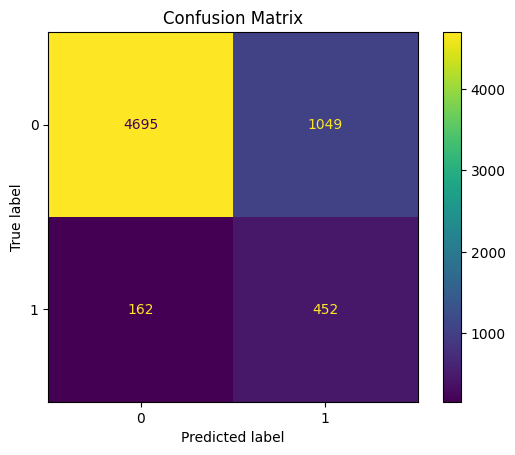

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_valid, y_pred)
plt.title("Confusion Matrix")
plt.show()

### ROC Curve

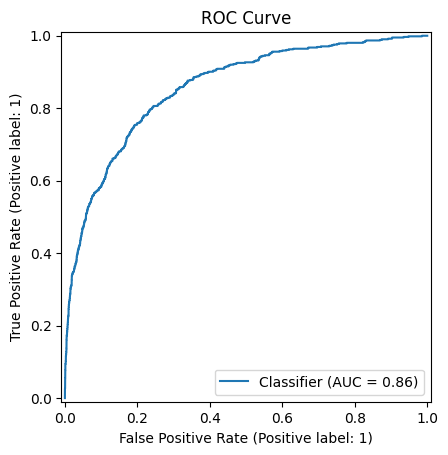

In [13]:
from sklearn.metrics import RocCurveDisplay

y_proba = cbc_2.predict_proba(X_valid)[:, 1]

RocCurveDisplay.from_predictions(y_valid, y_proba)
plt.title("ROC Curve")
plt.show()

### Precision-Recall Curve

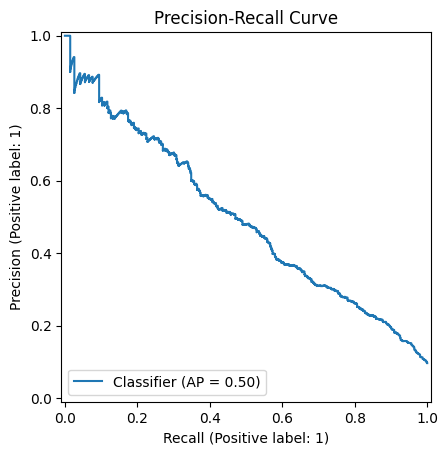

In [14]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_valid, y_proba)
plt.title("Precision-Recall Curve")
plt.show()

### Feature importance

               Feature  Importance
8      WildlifeSpecies   22.907658
6         WildlifeSize   21.692394
0          AirportName   12.797212
5          FlightPhase    8.046412
9             Altitude    7.900698
1   NumberStruckActual    6.977804
2                Month    6.166760
3                 Year    5.265516
10    IsAircraftLarge?    3.723464
7        ConditionsSky    2.444180
4              Engines    2.077901


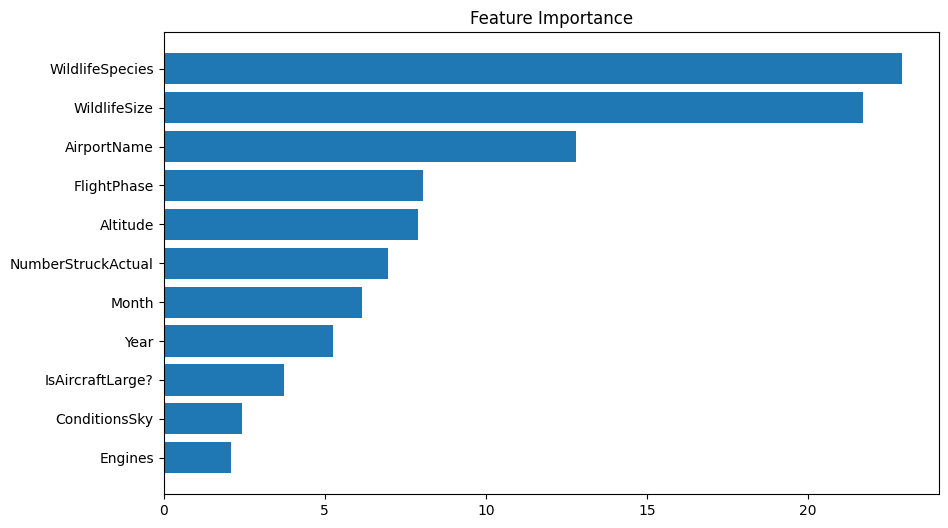

In [15]:
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": cbc_2.get_feature_importance()
}).sort_values(by="Importance", ascending=False)

print(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()